# Detección de Anomalías en Series de Tiempo:  Comparasión de Autoencoders (Convoluciones 1D  vs LSTM)

## Resumen Ejecutivo del Proyecto
Este proyecto compara dos autoencoders para detección de anomalías en series de tiempo: uno con capas Conv1D y otro con capas LSTM. Se trabajó con señales diarias normalizadas, ventanas temporales de 288 pasos (cada 5 minutos) y un enfoque de reconstrucción para identificar patrones inusuales por error MAE. 

## Problema
Detectar anomalías de forma confiable en una señal temporal. Se evaluó si una arquitectura secuencial (LSTM) supera a una convolucional (Conv1D) para reconstruir la señal temporal e identificar anomalías.

## Enfoque técnico
Se entrenaron ambos modelos con `validation_split=0.2`, early stopping y pérdida MSE. Luego se definió un umbral por modelo usando el MAE máximo en entrenamiento y se aplicó a test para identificar anomalías. Se compararon número de parámetros por autoencoder, tiempo de entrenamiento, curvas de pérdida, umbrales y número de anomalías detectadas.

## Resultados Principales
- Parámetros: Conv1D `9,505` vs LSTM `63,617`.
- Tiempo de entrenamiento: Conv1D `~65 s` vs LSTM `~3,427.7 s` (~57 min).
- Umbral MAE: Conv1D `0.0572` vs LSTM `0.3966`.
- Anomalías detectadas: Conv1D `111` vs LSTM `61`.
- Conv1D reconstruye mejor la señal anomala y detecta más eventos tempranos.

## Valor para Portafolio
Demuestra habilidades para analizar series de tiempo y detectar anomalías con deep Learning aplicado, evaluación de trade-offs (performance vs costo computacional).

# Descripción del Ret

- Este reto busca que los estudiantes comparen diferentes arquitecturas de auto-encoders.
- Utilice el notebook visto en clase link (DL_Bloque5_Timeseries_Anomaly_Detection.ipynb), y cambie la arquitectura de la red auto-encoder, donde usábamos Convoluciones 1D, y construya
una arquitectura de autoencoders con LSTM.
- Entrene la red construida y compárela con los resultados obtenidos en clase.

In [1]:
import numpy as np
import pandas as pd
import os
import time

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.models import load_model

from matplotlib import pyplot as plt

In [2]:
# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")

In [ ]:
# Cambiar reto4 por la carpeta reto5
path_wd = "/content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4/"
print(path_wd)
path_wd2 = path_wd.replace('reto4', 'reto5')
print(path_wd2)

In [ ]:
# Path a directorio de trabajo
dataset_file_noAnomaly = '/art_daily_small_noise.csv'
path_dir_dataset_noAnomaly = path_wd2 +  dataset_file_noAnomaly
print(path_dir_dataset_noAnomaly)

In [5]:
# "artificialNoAnomaly/art_daily_small_noise.csv"
df_small_noise = pd.read_csv(path_dir_dataset_noAnomaly,
                             parse_dates=True,
                             index_col="timestamp"
)
df_small_noise.head(5)

,value
timestamp,
2014-04-01 00:00:00,18.324919
2014-04-01 00:05:00,21.970327
2014-04-01 00:10:00,18.624806
2014-04-01 00:15:00,21.953684
2014-04-01 00:20:00,21.909120


In [6]:
# "artificialWithAnomaly/art_daily_jumpsup.csv"
path_dir_dataset_with_anomaly = path_wd2 + '/art_daily_jumpsup.csv'
df_daily_jumpsup = pd.read_csv(
    path_dir_dataset_with_anomaly, parse_dates=True, index_col="timestamp"
)
df_daily_jumpsup.head(5)

,value
timestamp,
2014-04-01 00:00:00,19.761252
2014-04-01 00:05:00,20.500833
2014-04-01 00:10:00,19.961641
2014-04-01 00:15:00,21.490266
2014-04-01 00:20:00,20.187739


## Visualización de los datos
### Series sin anomalías

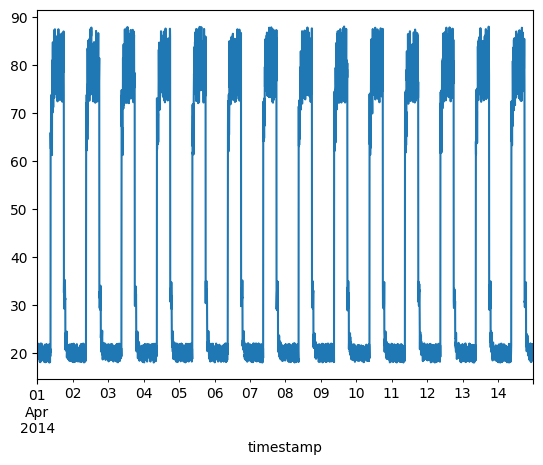

In [7]:
fig, ax = plt.subplots()
df_small_noise.plot(legend=False, ax=ax)
plt.show()

### Series con anomalías

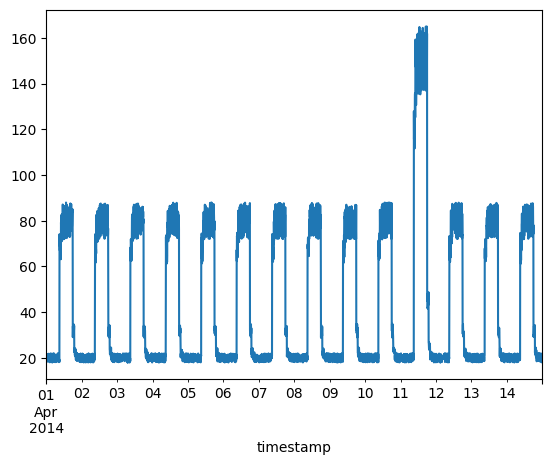

In [8]:
fig, ax = plt.subplots()
df_daily_jumpsup.plot(legend=False, ax=ax)
plt.show()

## Preprocesado

Obtenemos los valores del archivo de datos de la serie de tiempo de entrenamiento y normalizamos los datos de `value`. Tenemos un `value` cada 5 minutos durante 14 días.

* 24 * 60 / 5 = **288 pasos de tiempo por día**
* 288 * 14 = **4032 puntos de datos** en total"


In [9]:
training_mean = df_small_noise.mean()
training_std = df_small_noise.std()
df_training_value = (df_small_noise - training_mean) / training_std
print("Número de ejemplos de entrenamiento:", len(df_training_value))

Número de ejemplos de entrenamiento: 4032


### Creación de secuancias

In [10]:
TIME_STEPS = 288


# Generated training sequences for use in the model.
def create_sequences(values, time_steps=TIME_STEPS):
    output = []
    for i in range(len(values) - time_steps + 1):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)


x_train = create_sequences(df_training_value.values)
print("Training input shape: ", x_train.shape)

Training input shape:  (3745, 288, 1)


## Construcción de modelos

In [11]:
def conv1d_autoencoder_model(TIME_STEPS):
    """Autoencoder model architecture."""
    model = tf.keras.Sequential([
        layers.Input(shape=(TIME_STEPS, 1)),
        layers.Conv1D(filters=32, kernel_size=7, padding="same", strides=2, activation="relu",),
        layers.Dropout(rate=0.2),
        layers.Conv1D(filters=16, kernel_size=7, padding="same", strides=2, activation="relu",),

        layers.Conv1DTranspose(filters=16, kernel_size=7, padding="same", strides=2, activation="relu",),
        layers.Dropout(rate=0.2),
        layers.Conv1DTranspose(filters=32, kernel_size=7, padding="same", strides=2, activation="relu",),
        layers.Conv1DTranspose(filters=1, kernel_size=7, padding="same"),
    ])
    return model

def lstm_autoencoder_model(TIME_STEPS):
    """Autoencoder model architecture."""
    model = tf.keras.Sequential([
    # Encoder
    layers.Input(shape=(TIME_STEPS, 1)),
    layers.LSTM(64, activation='tanh', return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, activation='tanh', return_sequences=True),

    # Encaje
    layers.Dropout(0.2),
    layers.LSTM(16, activation='tanh', return_sequences=False),
    layers.RepeatVector(TIME_STEPS),

    # Decoder
    layers.LSTM(32, activation='tanh', return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, activation='tanh', return_sequences=True),
    layers.TimeDistributed(layers.Dense(1)),
    ])
    return model



In [12]:
#Crear modelos
all_models = {
    'CONV1_AUTOENCODER': conv1d_autoencoder_model(TIME_STEPS),
    'LSTM_AUTOENCODER': lstm_autoencoder_model(TIME_STEPS)}

# Compilar todos
for name, model in all_models.items():
    model.compile(optimizer='adam', loss='mse',
                  metrics=['mse'])

    #model.summary()
    print(f"\n{name} - Parámetros totales: {model.count_params():,}")


CONV1_AUTOENCODER - Parámetros totales: 9,505

LSTM_AUTOENCODER - Parámetros totales: 63,617


## Entrenamiento

In [13]:
history_dict = {}
results = []
num_epochs = 100
model_paths = []
batch_size = 300 #128

for name, model in all_models.items():
    print(f"\n{'='*50}")
    print(f"Entrenando {name}")
    print(f"{'='*50}")
    start_time = time.time()


    # Save best model callback
    checkpoint_path = path_wd + "/" + f'{name}_best.h5'
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    )

    history = model.fit(
        x_train, x_train,  # Autoencoder: input = output
        validation_split=0.2,
        epochs=num_epochs,
        callbacks=[
            checkpoint,
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
        ])

    train_time = time.time() - start_time

    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(history.history['loss']))

    # Guardar historia
    history_dict[name] = history.history

    # Métricas
    results.append({
        'Modelo': name,
        'Train_Loss': train_loss,
        'Val_Loss': val_loss,
        'Epochs_range': epochs_range,
        'Train_Time (s)': train_time,
        'Params': model.count_params()
    })

    print(f"\n{name} - Final Val_Loss: {val_loss[-1]:.4f}, Tiempo: {train_time:.1f}s")

    # Guardar mejor modelo
    model_paths.append(checkpoint_path)  # Use best model path
    print(f"Best model saved to: {checkpoint_path}")


Entrenando CONV1_AUTOENCODER
Epoch 1/100
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4377 - mse: 0.4377
Epoch 1: val_loss improved from inf to 0.03021, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//CONV1_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.4326 - mse: 0.4326 - val_loss: 0.0302 - val_mse: 0.0302
Epoch 2/100
92/94 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0408 - mse: 0.0408
Epoch 2: val_loss improved from 0.03021 to 0.02074, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//CONV1_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0407 - mse: 0.0407 - val_loss: 0.0207 - val_mse: 0.0207
Epoch 3/100
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0285 - mse: 0.0285
Epoch 3: val_loss improved from 0.02074 to 0.01841, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//CONV1_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0284 - mse: 0.0284 - val_loss: 0.0184 - val_mse: 0.0184
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0236 - mse: 0.0236
Epoch 4: val_loss did not improve from 0.01841
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0236 - mse: 0.0236 - val_loss: 0.0192 - val_mse: 0.0192
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0209 - mse: 0.0209
Epoch 5: val_loss improved from 0.01841 to 0.01659, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//CONV1_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0209 - mse: 0.0209 - val_loss: 0.0166 - val_mse: 0.0166
Epoch 6/100
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0190 - mse: 0.0190
Epoch 6: val_loss improved from 0.01659 to 0.01633, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//CONV1_AUTOENCODER_best.h5


...

94/94 ━━━━━━━━━━━━━━━━━━━━ 85s 907ms/step - loss: 0.7077 - mse: 0.7077 - val_loss: 0.4140 - val_mse: 0.4140
Epoch 23/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - loss: 0.4956 - mse: 0.4956
Epoch 23: val_loss did not improve from 0.41398
94/94 ━━━━━━━━━━━━━━━━━━━━ 83s 884ms/step - loss: 0.4961 - mse: 0.4961 - val_loss: 0.5403 - val_mse: 0.5403
Epoch 24/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - loss: 0.5651 - mse: 0.5651
Epoch 24: val_loss did not improve from 0.41398
94/94 ━━━━━━━━━━━━━━━━━━━━ 140s 865ms/step - loss: 0.5649 - mse: 0.5649 - val_loss: 0.4380 - val_mse: 0.4380
Epoch 25/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - loss: 0.5104 - mse: 0.5104
Epoch 25: val_loss improved from 0.41398 to 0.24663, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//LSTM_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 83s 878ms/step - loss: 0.5101 - mse: 0.5101 - val_loss: 0.2466 - val_mse: 0.2466
Epoch 26/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - loss: 0.2450 - mse: 0.2450
Epoch 26: val_loss improved from 0.24663 to 0.22168, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//LSTM_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 83s 887ms/step - loss: 0.2450 - mse: 0.2450 - val_loss: 0.2217 - val_mse: 0.2217
Epoch 27/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 866ms/step - loss: 0.1766 - mse: 0.1766
Epoch 27: val_loss improved from 0.22168 to 0.10684, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//LSTM_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 145s 924ms/step - loss: 0.1764 - mse: 0.1764 - val_loss: 0.1068 - val_mse: 0.1068
Epoch 28/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - loss: 0.1333 - mse: 0.1333
Epoch 28: val_loss improved from 0.10684 to 0.08538, saving model to /content/drive/MyDrive/Colab Notebooks/Bourbaki/math_and_deepLearning/reto4//LSTM_AUTOENCODER_best.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 872ms/step - loss: 0.1332 - mse: 0.1332 - val_loss: 0.0854 - val_mse: 0.0854
Epoch 29/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - loss: 0.1098 - mse: 0.1098
Epoch 29: val_loss did not improve from 0.08538
94/94 ━━━━━━━━━━━━━━━━━━━━ 83s 880ms/step - loss: 0.1097 - mse: 0.1097 - val_loss: 0.1083 - val_mse: 0.1083
Epoch 30/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - loss: 0.1186 - mse: 0.1186
Epoch 30: val_loss did not improve from 0.08538
94/94 ━━━━━━━━━━━━━━━━━━━━ 142s 881ms/step - loss: 0.1186 - mse: 0.1186 - val_loss: 0.1054 - val_mse: 0.1054
Epoch 31/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 847ms/step - loss: 0.1231 - mse: 0.1231
Epoch 31: val_loss did not improve from 0.08538
94/94 ━━━━━━━━━━━━━━━━━━━━ 144s 903ms/step - loss: 0.1234 - mse: 0.1234 - val_loss: 0.1743 - val_mse: 0.1743
Epoch 32/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - loss: 0.1295 - mse: 0.1295
Epoch 32: val_loss did not improve from 0.08538
94/94 ━━━━━━━━━━━━━━━━━━━━ 140s 878ms/step

In [14]:
def plot_loss_curves(results):
    if not results:
        raise ValueError("results is empty")

    plt.figure(figsize=(8, 5))
    for entry in results:
        name = entry.get('Modelo', 'Unnamed')
        train_loss = entry.get('Train_Loss', [])
        val_loss = entry.get('Val_Loss', [])
        epochs = entry.get('Epochs_range', list(range(1, len(train_loss) + 1)))

        plt.plot(epochs, train_loss, label=f"{name} - Train")
        plt.plot(epochs, val_loss, linestyle='--', label=f"{name} - Val")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


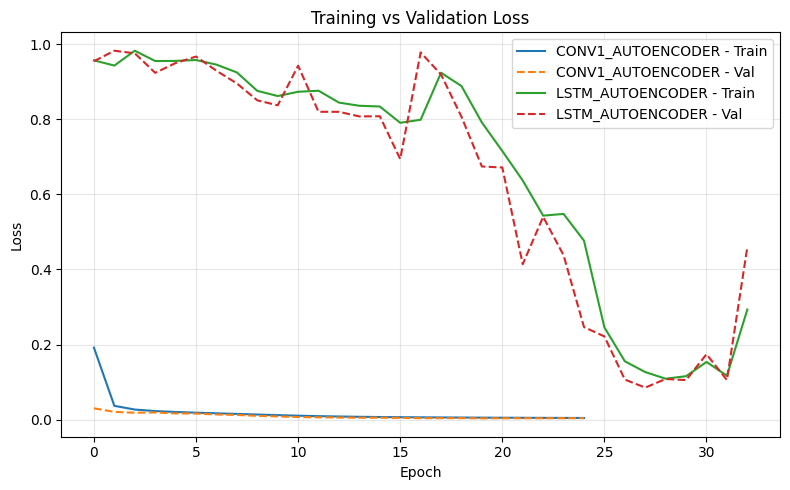

In [15]:
plot_loss_curves(results)

# Resultados Set de Entrenaminto vs Set de Validación

## Autoencoder con capas conv1D

- Número de parametros: 9,505.

- Utilizando early stoping, el entrenamiento converge luego de 25 épocas.

- El tiempo de entrenamiento fue de 65.0 segundos.

- Los valores de pérdida son muy similares entre el set de entrenamiento y el de validación, se observa un ligero sobre ajuste.


## Autoencoder con capas LSTM

- Número de parametros: 63,617.

- Utilizando early stoping, el entrenamiento  converge luego de 33 épocas.

- El tiempo de entrenamiento fue de 3427.7s segundos (~57 min).

- En la mayoría de las épocas el modelo generaliza mejor en el set de validación en comparación con el set de entrenamiento, sugiriendo sub-ajuste.


## Valores de pérdida

- Los valores de pérdida son más pequeños para el modelo de autoencoder contruido con capas convolucionales de 1 dimensión.

- Ambos modelos utilizan capas de dropout (0.2) para reducir el sobre ajuste.

## Detectando anomalías

Detectaremos anomalías determinando qué tan bien nuestro modelo puede reconstruir los datos de entrada.

1. Calcular la pérdida MAE en las muestras de entrenamiento.
2. Encontrar el valor máximo de la pérdida MAE. Este es el peor desempeño de nuestro modelo al intentar reconstruir una muestra. Usaremos este valor como el `umbral` para la detección de anomalías.
3. Si la pérdida de reconstrucción para una muestra es mayor que este valor `umbral`, entonces podemos inferir que el modelo está observando un patrón con el que no está familiarizado. Etiquetaremos esta muestra como una `anomalía`.


In [16]:
def evaluar_reconstruccion(model_path):
    model = load_model(model_path, compile=False)
    model.summary()

    # Extract model name from path
    model_name = model_path.split("/")[-1]

    # Obtenemos el MAE.
    x_train_pred = model.predict(x_train)
    train_mae_loss = np.mean(np.abs(x_train_pred - x_train), axis=1)

    plt.hist(train_mae_loss, bins=50)
    plt.xlabel(f"Train MAE loss + {model_name}")
    plt.ylabel("No of samples")
    plt.show()

    threshold = np.max(train_mae_loss)
    print("Reconstrucción del umbral de error: ", threshold)

    # Evaluación de la reconstrucción
    # Veamos cómo nuestro modelo ha reconstruido la primera muestra.
    # Esta corresponde a los **288 pasos de tiempo del día 1** de nuestro conjunto de entrenamiento.
    # Checking how the first sequence is learnt
    plt.plot(x_train[0])
    plt.plot(x_train_pred[0])
    plt.show()

    # Crear df con model_path y umbral
    df_results = pd.DataFrame({"model_path": [model_path], "threshold": [threshold]})

    return df_results

In [17]:
def find_anomalias(model_path, x_test, threshold, len_test):
    # Descripción
    """Función para detectar analomalias """
    model = load_model(model_path, compile=False)

    x_test_pred = model.predict(x_test)
    test_mae_loss = np.mean(np.abs(x_test_pred - x_test), axis=1)
    test_mae_loss = test_mae_loss.reshape((-1))
    # Extract model name from path
    model_name = model_path.split("/")[-1]

    plt.hist(test_mae_loss, bins=50)
    plt.xlabel(f"Test MAE loss + {model_name}")
    plt.ylabel("No of samples")
    plt.show()

    # Detect all the samples which are anomalies.
    anomalies = test_mae_loss > threshold
    print("Number of anomaly samples: ", np.sum(anomalies))
    print("Indices of anomaly samples: ", np.where(anomalies))

    anomalous_data_indices = []
    for data_idx in range(TIME_STEPS - 1, len_test - TIME_STEPS + 1):
        if np.all(anomalies[data_idx - TIME_STEPS + 1 : data_idx]):
            anomalous_data_indices.append(data_idx)

    return anomalous_data_indices


Evaluating model: CONV1_AUTOENCODER_best.h5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 144, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 72, 16)         │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 144, 16)        │         1,808 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 144, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 288, 32)        │         3,616 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 288, 1)         │           225 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505 (37.13 KB)

 Trainable params: 9,505 (37.13 KB)

 Non-trainable params: 0 (0.00 B)

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


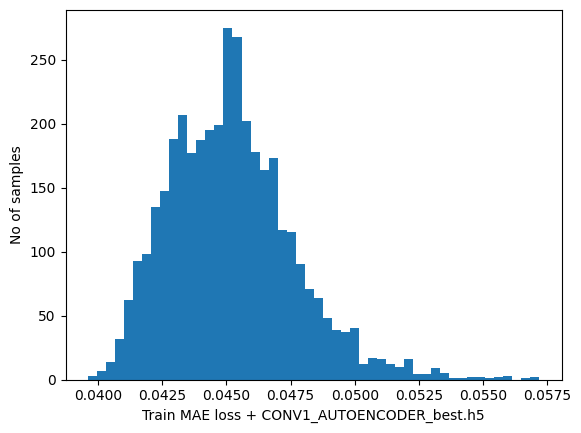

Reconstrucción del umbral de error:  0.05717426872985196


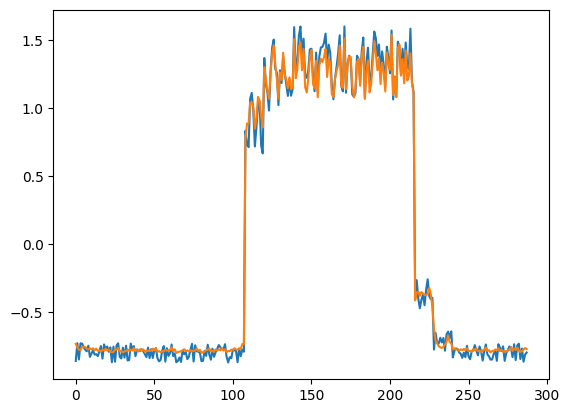


Evaluating model: LSTM_AUTOENCODER_best.h5


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 288, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 288, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 288, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 288, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 288, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 288, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 288, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 288, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 288, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,617 (248.50 KB)

 Trainable params: 63,617 (248.50 KB)

 Non-trainable params: 0 (0.00 B)

118/118 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms/step


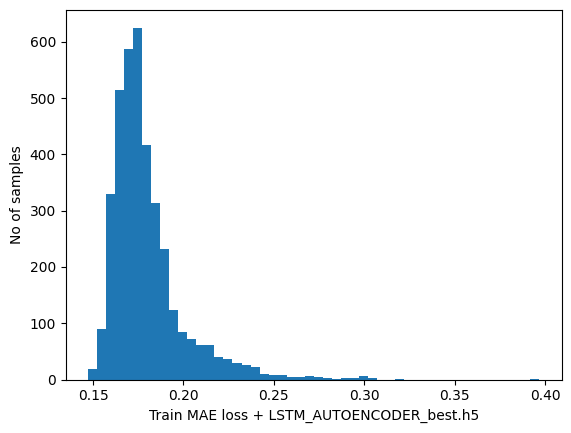

Reconstrucción del umbral de error:  0.39662559375163664


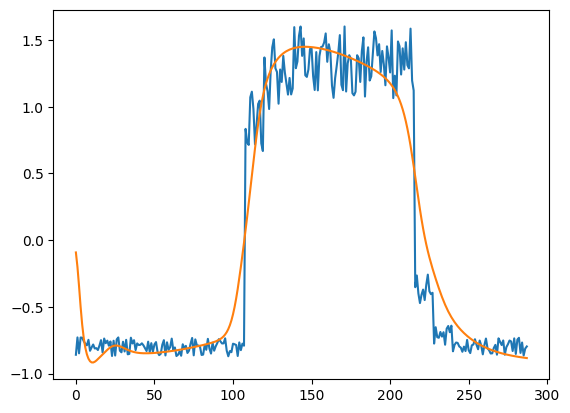

In [18]:
resultados_train_set_df = pd.DataFrame()

for model_path in model_paths:

    # Extract model name from path
    model_name = model_path.split("/")[-1]
    print(f"\n{'='*60}")
    print(f"Evaluating model: {model_name}")
    print(f"{'='*60}")

    res_eval_df = evaluar_reconstruccion(model_path)

    # Append results to the main DataFrame
    resultados_train_set_df = pd.concat([resultados_train_set_df, res_eval_df],
                                        ignore_index=True)


# Resultados Evaluación de la Reconstrucción

- Los valores de MAE  son menores para el autoencoder-CONV1D (0.04 -0.05), por tanto captura mejor las variaciones y patrones observados en la serie de tiempo original, mientras que el autoencoder-LSTM, aprende solamente la tendencia global.


### Preparación de los datos test

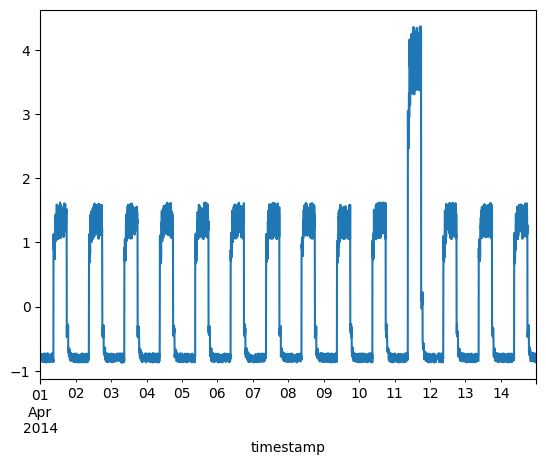

Test input shape:  (3745, 288, 1)


In [19]:
df_test_value = (df_daily_jumpsup - training_mean) / training_std
fig, ax = plt.subplots()
df_test_value.plot(legend=False, ax=ax)
plt.show()

# Obtener número de ejemplos en el set de test
len_df_test_value = len(df_test_value)

x_test = create_sequences(df_test_value.values)
print("Test input shape: ", x_test.shape)




## Plot de anomalías

Ahora ya conocemos las muestras de los datos que son anomalías. Con esto, encontraremos las `timestamps` correspondientes a partir de los datos originales de prueba. Usaremos el siguiente método para hacerlo:

Supongamos que **time_steps = 3** y tenemos **10 valores de entrenamiento**. Nuestro `x_train` se verá así:

* 0, 1, 2
* 1, 2, 3
* 2, 3, 4
* 3, 4, 5
* 4, 5, 6
* 5, 6, 7
* 6, 7, 8
* 7, 8, 9

Excepto los valores iniciales y finales (time_steps - 1), todos los demás aparecerán en `time_steps` muestras distintas. Por lo tanto, si sabemos que las muestras
[(3, 4, 5), (4, 5, 6), (5, 6, 7)]
son anomalías, podemos decir que el punto de dato **5** es una anomalía.




Detección de anomalías con modelo: CONV1_AUTOENCODER_best.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


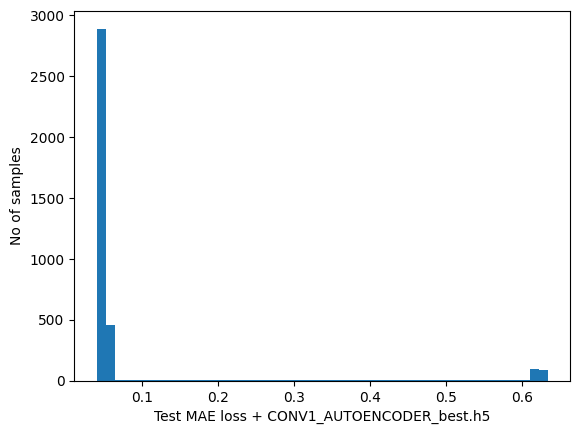

Number of anomaly samples:  416
Indices of anomaly samples:  (array([ 775,  776,  780,  790,  792,  793,  972,  973, 1657, 2122, 2123,
       2126, 2519, 2698, 2699, 2701, 2702, 2703, 2704, 2705, 2706, 2707,
       2708, 2709, 2710, 2711, 2712, 2713, 2714, 2715, 2716, 2717, 2718,
       2719, 2720, 2721, 2722, 2723, 2724, 2725, 2726, 2727, 2728, 2729,
       2730, 2731, 2732, 2733, 2734, 2735, 2736, 2737, 2738, 2739, 2740,
       2741, 2742, 2743, 2744, 2745, 2746, 2747, 2748, 2749, 2750, 2751,
       2752, 2753, 2754, 2755, 2756, 2757, 2758, 2759, 2760, 2761, 2762,
       2763, 2764, 2765, 2766, 2767, 2768, 2769, 2770, 2771, 2772, 2773,
       2774, 2775, 2776, 2777, 2778, 2779, 2780, 2781, 2782, 2783, 2784,
       2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2793, 2794, 2795,
       2796, 2797, 2798, 2799, 2800, 2801, 2802, 2803, 2804, 2805, 2806,
       2807, 2808, 2809, 2810, 2811, 2812, 2813, 2814, 2815, 2816, 2817,
       2818, 2819, 2820, 2821, 2822, 2823, 2824, 2825, 2826, 2

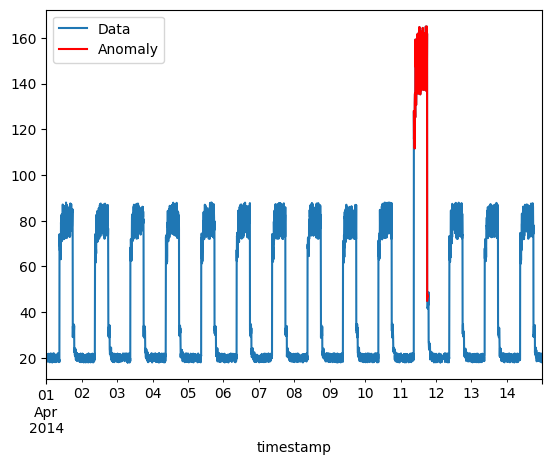


Detección de anomalías con modelo: LSTM_AUTOENCODER_best.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 173ms/step


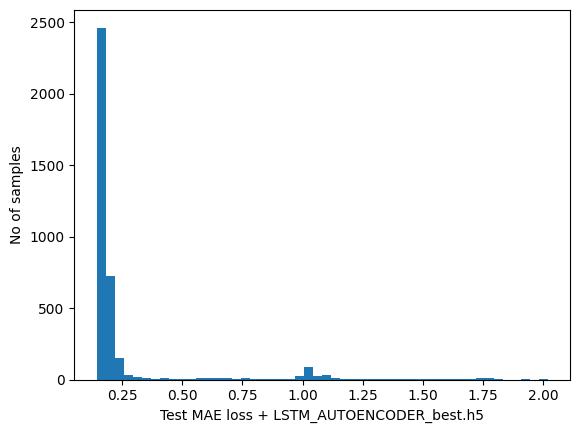

Number of anomaly samples:  347
Indices of anomaly samples:  (array([2724, 2725, 2726, 2727, 2728, 2729, 2730, 2731, 2732, 2733, 2734,
       2735, 2736, 2737, 2738, 2739, 2740, 2741, 2742, 2743, 2744, 2745,
       2746, 2747, 2748, 2749, 2750, 2751, 2752, 2753, 2754, 2755, 2756,
       2757, 2758, 2759, 2760, 2761, 2762, 2763, 2764, 2765, 2766, 2767,
       2768, 2769, 2770, 2771, 2772, 2773, 2774, 2775, 2776, 2777, 2778,
       2779, 2780, 2781, 2782, 2783, 2784, 2785, 2786, 2787, 2788, 2789,
       2790, 2791, 2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799, 2800,
       2801, 2802, 2803, 2804, 2805, 2806, 2807, 2808, 2809, 2810, 2811,
       2812, 2813, 2814, 2815, 2816, 2817, 2818, 2819, 2820, 2821, 2822,
       2823, 2824, 2825, 2826, 2827, 2828, 2829, 2830, 2831, 2832, 2833,
       2834, 2835, 2836, 2837, 2838, 2839, 2840, 2841, 2842, 2843, 2844,
       2845, 2846, 2847, 2848, 2849, 2850, 2851, 2852, 2853, 2854, 2855,
       2856, 2857, 2858, 2859, 2860, 2861, 2862, 2863, 2864, 2

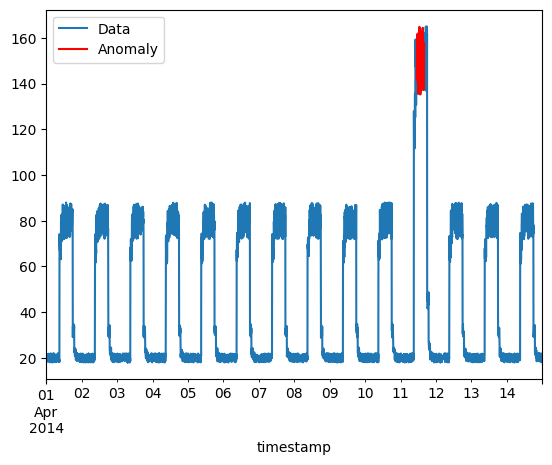

In [20]:
for model_path in model_paths:

    anomalous_data_indices = []

    # Extract model name from path
    model_name = model_path.split("/")[-1]
    print(f"\n{'='*60}")
    print(f"Detección de anomalías con modelo: {model_name}")
    print(f"{'='*60}")

    # Obtener umbral del modelo
    threshold = resultados_train_set_df.loc[resultados_train_set_df['model_path'] == model_path, 'threshold'].values[0]

    # Detectar anomalías en el conjunto de prueba
    anomalous_data_indices = find_anomalias(model_path, x_test, threshold, len_df_test_value)

    # Visualizar anomalías detectadas
    df_subset = df_daily_jumpsup.iloc[anomalous_data_indices]
    print(f"Anomalias encontradas: {len(df_subset)}")

    fig, ax = plt.subplots()
    df_daily_jumpsup.plot(legend=False, ax=ax)

    if not df_subset.empty:
      df_subset.plot(legend=False, ax=ax, color="r")
      #add  legend
      ax.legend(["Data", "Anomaly"])

    plt.show()

# Resultados Detección de anomalías

- La señal anomala se observa aproximadamente en valores arriba de 90.

## Autoencoder con capas conv1D

- Este modelo detecta 111 anomalías, incluyendo algunos valores dentro del rango normal.

## Autoencoder con capas LSTM

- Este modelo detecta 61 anomalías, capturando un subconjunto importante de los valores más elevados de la serie de tiempo.

## Conclusiones

-  El autoencoder con capas conv1D, logra una mejor reconstrucción de la serie de tiempo original, su entrenamiento tarda 1 minuto vs. 1 hora del LSTM. En general detecta más puntos anomalos en tiempos más tempranos, aunque incluye algunos falsos positivos.
